In [ ]:
# ML

#import data set

!pip install medmnist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.5 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256

In [ ]:
import medmnist
print(medmnist.__version__)

3.0.2


In [ ]:
from medmnist import DermaMNIST
train_dataset = DermaMNIST(split="train", download=True)

100%|██████████| 19.7M/19.7M [00:09<00:00, 2.18MB/s]


In [ ]:
from medmnist import DermaMNIST
test_dataset = DermaMNIST(split="test", download=True)

In [ ]:
# List all available dataset
from medmnist import DermaMNIST
from medmnist import INFO

# Load the dataset
data_flag = 'dermamnist'
download = True
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
dataset = DataClass(split='train', download=download)


In [ ]:
from medmnist import DermaMNIST
val_dataset = DermaMNIST(split="val", download=True)

In [ ]:
from medmnist import DermaMNIST

# Load training, testing, and validation datasets
train_dataset = DermaMNIST(split="train", download=True)
test_dataset = DermaMNIST(split="test", download=True)
val_dataset = DermaMNIST(split="val", download=True)


In [ ]:
import numpy as np

# Save the images and labels
images = dataset.imgs
labels = dataset.labels

np.save('dermamnist_images.npy', images)
np.save('dermamnist_labels.npy', labels)


In [ ]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, Evaluator

In [ ]:
import medmnist
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")


MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


# We first work on a 2D dataset with size 28x28

In [ ]:
data_flag = 'dermamnist'
download = True
NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001
info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])

In [ ]:
# Preprocessing
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
# Load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
#Encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [ ]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 7007
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0
Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 200

In [ ]:
# visualization

train_dataset.montage(length=1)

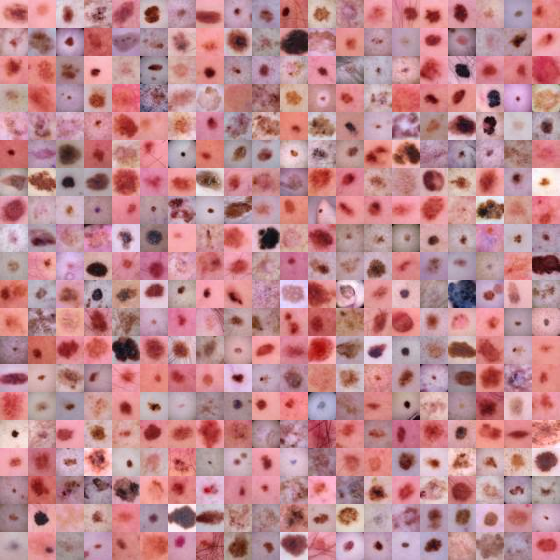

In [ ]:
# montage

train_dataset.montage(length=20)

In [ ]:
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern, hog
from skimage import exposure
import cv2

# def extract_color_histogram(image, bins=(8, 8, 8)):
#     # Convert the image to HSV color-space
#     hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
#     # Compute the color histogram
#     hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 256, 0, 256, 0, 256])
#     # Normalize the histogram
#     hist = cv2.normalize(hist, hist).flatten()
#     return hist



In [ ]:
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern, hog
from skimage import exposure
import cv2

def extract_color_histogram(image, bins=(8, 8, 8)):
    # Convert the image to HSV color-space
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    # Compute the color histogram
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 256, 0, 256, 0, 256])
    # Normalize the histogram
    hist = cv2.normalize(hist, hist).flatten()
    return hist

In [ ]:
def extract_hog_features(image):
    # Convert the image to grayscale
    gray = rgb2gray(image)
    # Compute HOG features
    hog_features, hog_image = hog(gray, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    return hog_features



In [ ]:
def extract_lbp_features(image, P=8, R=1):
    # Convert the image to grayscale
    gray = rgb2gray(image)
    # Compute LBP features
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    # Compute the histogram of LBP
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, P + 3), range=(0, P + 2))
    # Normalize the histogram
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist


In [ ]:
def extract_features(image):
    color_hist = extract_color_histogram(image)
    hog_features = extract_hog_features(image)
    lbp_features = extract_lbp_features(image)
    return np.hstack([color_hist, hog_features, lbp_features])

# def extract_features(image):
#     color_hist = extract_color_histogram(image)
#     hog_features = extract_hog_features(image)
#     lbp_features = extract_lbp_features(image)
#     return np.hstack([color_hist, hog_features, lbp_features])


In [ ]:
def extract_features_from_dataset(dataset):
    features = []
    labels = []
    for img, label in dataset:
        img = img.permute(1, 2, 0).numpy()  # Convert to HWC format
        feature = extract_features(img)
        features.append(feature)
        labels.append(label)
    return np.array(features), np.array(labels)

# Extract features for train, validation, and test datasets
X_train, y_train = extract_features_from_dataset(train_dataset)
X_val, y_val = extract_features_from_dataset(val_dataset)
X_test, y_test = extract_features_from_dataset(test_dataset)



/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve

# Initialize the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

# Validate the model
y_val_pred = log_reg.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_class_report = classification_report(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, log_reg.predict_proba(X_val), multi_class='ovr')

print(f"Validation Accuracy: {val_accuracy}")
print("Validation Confusion Matrix:")
print(val_conf_matrix)
print("Validation Classification Report:")
print(val_class_report)
print(f"Validation ROC-AUC: {val_roc_auc}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Validation Accuracy: 0.6829511465603191
Validation Confusion Matrix:
[[  1   3  10   0   1  18   0]
 [  2   5   6   0   0  39   0]
 [  4   1  16   0   2  87   0]
 [  0   0   2   0   0  10   0]
 [  0   2   9   0   0 100   0]
 [  2   0   5   0   1 663   0]
 [  1   0   1   0   0  12   0]]
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.03      0.05        33
           1       0.45      0.10      0.16        52
           2       0.33      0.15      0.20       110
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00       111
           5       0.71      0.99      0.83       671
           6       0.00      0.00      0.00        14

    accuracy                           0.68      1003
   macro avg       0.23      0.18      0.18      1003
weighted avg       0.54      0.68      0.59      1003

Validation ROC-AUC: 0.7567564828147784


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
# Test the model
y_test_pred = log_reg.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test), multi_class='ovr')

print("\nTesting Results:")
print(f"Test Accuracy: {test_accuracy}")
print("Test Confusion Matrix:")
print(test_conf_matrix)
print("Test Classification Report:")
print(test_class_report)
print(f"Test ROC-AUC: {test_roc_auc}")


Testing Results:
Test Accuracy: 0.6817955112219451
Test Confusion Matrix:
[[  14   12    8    0    0   32    0]
 [   3   12   10    0    1   77    0]
 [   9   17   29    0    0  165    0]
 [   2    1    2    0    0   18    0]
 [   5   11    8    0    2  197    0]
 [   5    9   17    0    0 1310    0]
 [   0    0    0    0    0   29    0]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.21      0.27        66
           1       0.19      0.12      0.15       103
           2       0.39      0.13      0.20       220
           3       0.00      0.00      0.00        23
           4       0.67      0.01      0.02       223
           5       0.72      0.98      0.83      1341
           6       0.00      0.00      0.00        29

    accuracy                           0.68      2005
   macro avg       0.33      0.21      0.21      2005
weighted avg       0.62      0.68      0.59      2005

Test ROC-AUC: 0.7479640963275521


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVM

In [45]:
from sklearn.svm import SVC

# Initialize the SVM model
svm_model = SVC(probability=True)

# Train the model
svm_model.fit(X_train, y_train)

# Validate the model
y_val_pred = svm_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_class_report = classification_report(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, svm_model.predict_proba(X_val), multi_class='ovr')

print(f"Validation Accuracy: {val_accuracy}")
print("Validation Confusion Matrix:")
print(val_conf_matrix)
print("Validation Classification Report:")
print(val_class_report)
print(f"Validation ROC-AUC: {val_roc_auc}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning

Validation Accuracy: 0.7278165503489531
Validation Confusion Matrix:
[[  9   7   8   0   1   8   0]
 [  5  10   8   0   0  29   0]
 [  3   8  41   0   4  54   0]
 [  0   5   0   0   0   7   0]
 [  1   4  10   0  16  80   0]
 [  0   2  13   0   2 654   0]
 [  1   0   1   0   0  12   0]]
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.27      0.35        33
           1       0.28      0.19      0.23        52
           2       0.51      0.37      0.43       110
           3       0.00      0.00      0.00        12
           4       0.70      0.14      0.24       111
           5       0.77      0.97      0.86       671
           6       0.00      0.00      0.00        14

    accuracy                           0.73      1003
   macro avg       0.39      0.28      0.30      1003
weighted avg       0.68      0.73      0.67      1003

Validation ROC-AUC: 0.8767250583512018


In [46]:
# Test the model
y_test_pred = svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, svm_model.predict_proba(X_test), multi_class='ovr')

print(f"Test Accuracy: {test_accuracy}")
print("Test Confusion Matrix:")
print(test_conf_matrix)
print("Test Classification Report:")
print(test_class_report)
print(f"Test ROC-AUC: {test_roc_auc}")


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test Accuracy: 0.7162094763092269
Test Confusion Matrix:
[[  17   14   12    0    2   21    0]
 [   6   27   18    0    1   51    0]
 [   8    9   76    0   11  116    0]
 [   3    1    3    0    0   16    0]
 [   5    3   31    0   16  168    0]
 [   1   13   17    0   10 1300    0]
 [   0    1    2    0    0   26    0]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.26      0.32        66
           1       0.40      0.26      0.32       103
           2       0.48      0.35      0.40       220
           3       0.00      0.00      0.00        23
           4       0.40      0.07      0.12       223
           5       0.77      0.97      0.86      1341
           6       0.00      0.00      0.00        29

    accuracy                           0.72      2005
   macro avg       0.35      0.27      0.29      2005
weighted avg       0.64      0.72      0.66      2005

Test ROC-AUC: 0.859064967073261


Gradient Boosting

In [47]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100)

# Train the model
gb_model.fit(X_train, y_train)

# Validate the model
y_val_pred = gb_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_class_report = classification_report(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, gb_model.predict_proba(X_val), multi_class='ovr')

print(f"Validation Accuracy: {val_accuracy}")
print("Validation Confusion Matrix:")
print(val_conf_matrix)
print("Validation Classification Report:")
print(val_class_report)
print(f"Validation ROC-AUC: {val_roc_auc}")


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Validation Accuracy: 0.7407776669990029
Validation Confusion Matrix:
[[  6   6  11   0   2   8   0]
 [  3  16  10   0   3  19   1]
 [  3  11  42   0   9  44   1]
 [  2   4   0   1   0   5   0]
 [  0   2  10   0  40  58   1]
 [  1   4  11   2  15 636   2]
 [  1   1   0   2   0   8   2]]
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.18      0.24        33
           1       0.36      0.31      0.33        52
           2       0.50      0.38      0.43       110
           3       0.20      0.08      0.12        12
           4       0.58      0.36      0.44       111
           5       0.82      0.95      0.88       671
           6       0.29      0.14      0.19        14

    accuracy                           0.74      1003
   macro avg       0.45      0.34      0.38      1003
weighted avg       0.70      0.74      0.71      1003

Validation ROC-AUC: 0.8616654692937971


In [48]:
# Test the model
y_test_pred = gb_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)
test_class_report = classification_report(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test), multi_class='ovr')

print(f"Test Accuracy: {test_accuracy}")
print("Test Confusion Matrix:")
print(test_conf_matrix)
print("Test Classification Report:")
print(test_class_report)
print(f"Test ROC-AUC: {test_roc_auc}")


Test Accuracy: 0.7221945137157108
Test Confusion Matrix:
[[  17   13   13    0    7   16    0]
 [   9   27   16    0    1   48    2]
 [   5   15   79    1   18  101    1]
 [   1    3    1    0    1   17    0]
 [   7    1   25    0   64  124    2]
 [   3    9   20    5   39 1255   10]
 [   0    3    0    0    1   19    6]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.26      0.31        66
           1       0.38      0.26      0.31       103
           2       0.51      0.36      0.42       220
           3       0.00      0.00      0.00        23
           4       0.49      0.29      0.36       223
           5       0.79      0.94      0.86      1341
           6       0.29      0.21      0.24        29

    accuracy                           0.72      2005
   macro avg       0.41      0.33      0.36      2005
weighted avg       0.68      0.72      0.69      2005

Test ROC-AUC: 0.8585843215514786


CNN

In [54]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from medmnist import DermaMNIST
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Define a simple CNN model
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x



In [55]:
# Initialize the CNN model
model = CNN(in_channels=3, num_classes=7)  # Assuming 3 channels (RGB) and 7 classes

# Data preprocessing and augmentation
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the data with transformations
train_dataset = DermaMNIST(split="train", transform=data_transform, download=True)
test_dataset = DermaMNIST(split="test", transform=data_transform, download=True)
val_dataset = DermaMNIST(split="val", transform=data_transform, download=True)




In [56]:
# Encapsulate data into dataloader form
BATCH_SIZE = 128
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



In [57]:
# Training the model
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        targets = targets.squeeze().long()  # Ensure targets are the correct shape and type
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {running_loss/len(train_loader)}")



Epoch [1/10], Loss: 4.9525726838545365
Epoch [2/10], Loss: 0.943273744799874
Epoch [3/10], Loss: 0.9155398758974942
Epoch [4/10], Loss: 0.7704887357625094
Epoch [5/10], Loss: 0.7243046110326593
Epoch [6/10], Loss: 0.6910461295734752
Epoch [7/10], Loss: 0.668533509427851
Epoch [8/10], Loss: 0.6325622780756517
Epoch [9/10], Loss: 0.5963110522790389
Epoch [10/10], Loss: 0.5592741104689511


In [58]:
# Validate the model
model.eval()
val_correct = 0
val_total = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        val_total += targets.size(0)
        val_correct += (predicted == targets).sum().item()

val_accuracy = val_correct / val_total
print(f"Validation Accuracy: {val_accuracy}")



Validation Accuracy: 67.40279162512462


In [59]:
# Test the model
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += targets.size(0)
        test_correct += (predicted == targets).sum().item()

test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 67.56259351620947


In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Convert predictions and targets to numpy arrays for metric calculations
def get_predictions_and_targets(loader, model):
    all_preds = []
    all_targets = []
    all_probs = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_targets), np.array(all_probs)





In [63]:
# Get predictions, targets, and probabilities for validation and test sets
val_preds, val_targets, val_probs = get_predictions_and_targets(val_loader, model)
test_preds, test_targets, test_probs = get_predictions_and_targets(test_loader, model)



In [64]:
# Calculate metrics for validation set
val_precision = precision_score(val_targets, val_preds, average='weighted')
val_recall = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
val_roc_auc = roc_auc_score(val_targets, val_probs, multi_class='ovr')


In [65]:
print(f"Validation Precision: {val_precision}")
print(f"Validation Recall: {val_recall}")
print(f"Validation F1 Score: {val_f1}")
print(f"Validation ROC-AUC: {val_roc_auc}")



Validation Precision: 0.7089273772837602
Validation Recall: 0.7407776669990029
Validation F1 Score: 0.7114887527848245
Validation ROC-AUC: 0.91202105583848


In [66]:
# Calculate metrics for test set
test_precision = precision_score(test_targets, test_preds, average='weighted')
test_recall = recall_score(test_targets, test_preds, average='weighted')
test_f1 = f1_score(test_targets, test_preds, average='weighted')
test_roc_auc = roc_auc_score(test_targets, test_probs, multi_class='ovr')


In [67]:

print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")
print(f"Test ROC-AUC: {test_roc_auc}")

Test Precision: 0.6915455495753329
Test Recall: 0.7321695760598503
Test F1 Score: 0.7004766775652657
Test ROC-AUC: 0.9042096873155826
